In [1]:
import pandas as pd
import numpy as np
df = pd.DataFrame(
    {
        "id":[1,2,3,4,5,6],
        "raw_grade":["a","b","a","a","b","e"]
    }
)
df["grades"] = df["raw_grade"].astype("category")
print(df["grades"])

new_categories = ["very good","good","very bad"]
## .cat -> is a pandas accessor , give access to categorical-specific methods
df["grades"] = df["grades"].cat.rename_categories(new_categories) ## works when "grades" is categorical & new_catgory length matches
print(df)

## defines the complete list of allowed categories, if already existing cat is not in new list , then it will become NaN
## And also order/reorder category list
df["grades"] = df["grades"].cat.set_categories(["very bad","bad","medium","good","very good"])
print(df)
print(df.sort_values(by="grades"))

## Observed = False , group by all cat whether it present or not , it is also default behaviour
print(df.groupby("grades",observed=False).size()) ## observed in groupby is only for categorical data
print(df.groupby("grades",observed=True).count()) ## only for actually present categories 
print(df.groupby("grades").sum()) ## sum() -> concatenates for string , + means concat -> python behaviour , sum() internally applies +

0    a
1    b
2    a
3    a
4    b
5    e
Name: grades, dtype: category
Categories (3, object): ['a', 'b', 'e']
   id raw_grade     grades
0   1         a  very good
1   2         b       good
2   3         a  very good
3   4         a  very good
4   5         b       good
5   6         e   very bad
   id raw_grade     grades
0   1         a  very good
1   2         b       good
2   3         a  very good
3   4         a  very good
4   5         b       good
5   6         e   very bad
   id raw_grade     grades
5   6         e   very bad
1   2         b       good
4   5         b       good
0   1         a  very good
2   3         a  very good
3   4         a  very good
grades
very bad     1
bad          0
medium       0
good         2
very good    3
dtype: int64
           id  raw_grade
grades                  
very bad    1          1
good        2          2
very good   3          3
           id raw_grade
grades                 
very bad    6         e
bad         0         0
mediu

C:\Users\dell\AppData\Local\Temp\ipykernel_17704\339971008.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("grades").sum()) ## sum() -> concatenates for string , + means concat -> python behaviour , sum() internally applies +


2025-01-01    126
2025-01-02    299
2025-01-03    879
2025-01-04    479
2025-01-05    247
             ... 
2027-09-23    306
2027-09-24    848
2027-09-25    198
2027-09-26    979
2027-09-27    316
Freq: D, Length: 1000, dtype: int32
Axes(0.125,0.11;0.775x0.77)


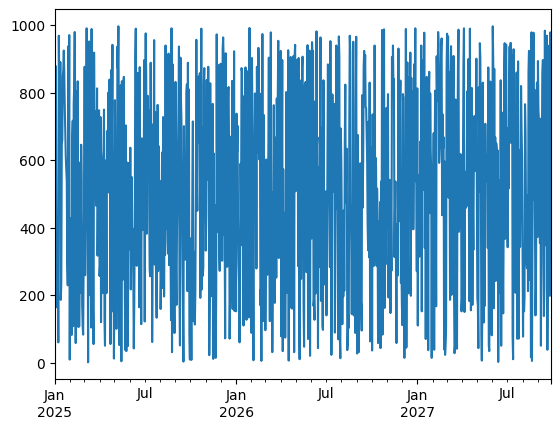

In [2]:
## Plotting

import matplotlib.pyplot as plt
plt.close("all") ## closes figure window

index = pd.date_range("1/1/2025",periods=1000)
ts = pd.Series(np.random.randint(0,1000,size=1000),index=index)
print(ts)

print(ts.plot())

Axes(0.125,0.11;0.775x0.77)


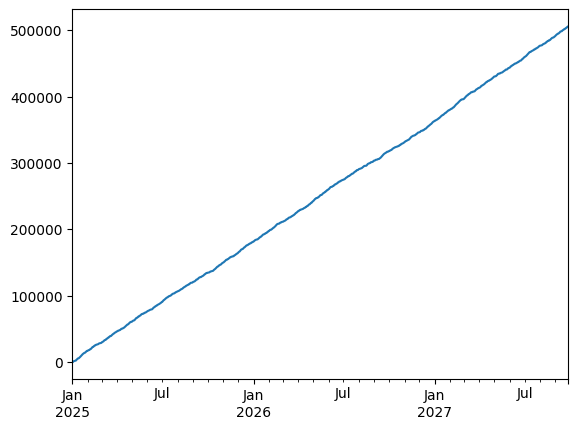

In [3]:
ts = ts.cumsum() ## adding all previous values to current value, for index 0 = index 0 , index1 = index 0 + index1 , index2 = index 0 + index 1+ index2
print(ts.plot())

Figure(640x480)
Axes(0.125,0.11;0.775x0.77)


<Figure size 640x480 with 0 Axes>

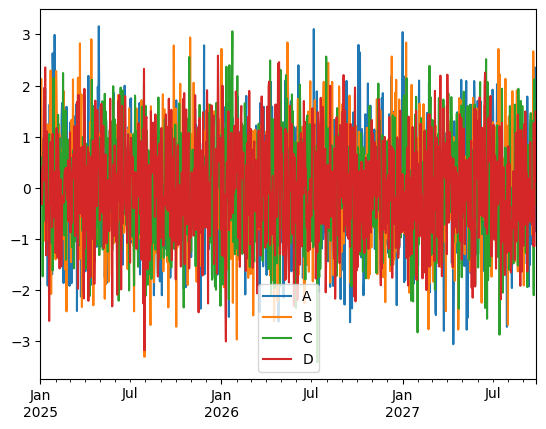

In [4]:
df = pd.DataFrame(np.random.randn(1000,4),index = ts.index , columns=["A","B","C","D"])


print(plt.figure()) ## creates a new window(figure)
print(df.plot())
plt.legend(loc="best") ## creates a legend , best -> auto place

Axes(0.125,0.11;0.775x0.77)


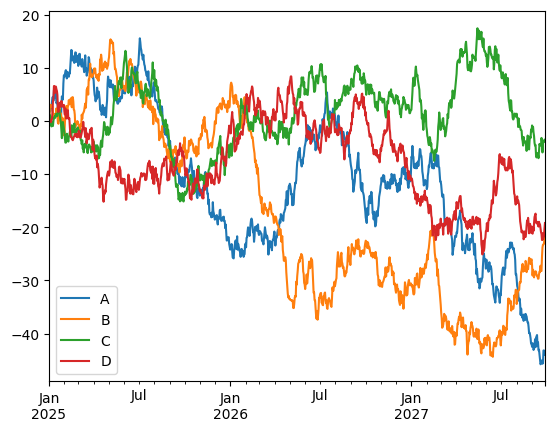

In [5]:
df = df.cumsum()
print(df.plot()) ## by default also legend will be in "best"(auto place)


In [6]:
## Importing and Exporting Data

df = pd.DataFrame(np.random.randint(0,5,(10,5)))
df.to_csv("data1.csv")
pd.read_csv("data1.csv")

,Unnamed: 0,0,1,2,3,4
0,0,4,4,3,1,1
1,1,3,4,1,4,0
2,2,2,0,4,1,0
3,3,0,0,2,0,3
4,4,3,4,2,0,3
5,5,3,1,1,1,2
6,6,0,4,4,1,4
7,7,2,1,0,2,4
8,8,3,2,4,3,1
9,9,2,1,1,0,4


In [7]:
df.to_parquet("data2.parquet")
pd.read_parquet("data2.parquet")
# | Feature        | Parquet                | CSV       |
# | -------------- | ---------------------- | --------- |
# | Storage        | Columnar               | Row-based |
# | File size      | ✅ Smaller (compressed) | ❌ Larger  |
# | Speed          | ✅ Faster reads         | ❌ Slower  |
# | Data types     | ✅ Preserved            | ❌ Lost    |
# | Big data tools | ✅ Supported            | ❌ Limited |


,0,1,2,3,4
0,4,4,3,1,1
1,3,4,1,4,0
2,2,0,4,1,0
3,0,0,2,0,3
4,3,4,2,0,3
5,3,1,1,1,2
6,0,4,4,1,4
7,2,1,0,2,4
8,3,2,4,3,1
9,2,1,1,0,4


In [ ]:
df.to_excel("data3.xlsx",sheet_name="sheet1")
#index_col=None -> Do not use any column from excel as dataframe index, pandas will create default integer index, index_col = 0, 1st col becomes index
## na_values=["NA"] -> Treat the string "NA" (missing data) as NaN
pd.read_excel("data3.xlsx",sheet_name="sheet1",index_col=None,na_values=["NA"])

,Unnamed: 0,0,1,2,3,4
0,0,4,4,3,1,1
1,1,3,4,1,4,0
2,2,2,0,4,1,0
3,3,0,0,2,0,3
4,4,3,4,2,0,3
5,5,3,1,1,1,2
6,6,0,4,4,1,4
7,7,2,1,0,2,4
8,8,3,2,4,3,1
9,9,2,1,1,0,4
